17th July, 2026

Upload the cleaned dataset

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\jayal\leaned_online_retail.csv")

In [2]:
df[['InvoiceMonth','CohortMonth']].dtypes

InvoiceMonth    object
CohortMonth     object
dtype: object

In [3]:
df['InvoiceMonth'] = pd.to_datetime(df['InvoiceMonth']).dt.to_period('M')
df['CohortMonth'] = pd.to_datetime(df['CohortMonth']).dt.to_period('M')

In [4]:
df[['InvoiceMonth','CohortMonth']].dtypes

InvoiceMonth    period[M]
CohortMonth     period[M]
dtype: object

In [5]:
#Cohort Index
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

In [6]:
df[['CustomerID','InvoiceMonth','CohortMonth','CohortIndex']].head(20)

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,0
1,17850.0,2010-12,2010-12,0
2,17850.0,2010-12,2010-12,0
3,17850.0,2010-12,2010-12,0
4,17850.0,2010-12,2010-12,0
5,17850.0,2010-12,2010-12,0
6,17850.0,2010-12,2010-12,0
7,17850.0,2010-12,2010-12,0
8,17850.0,2010-12,2010-12,0
9,13047.0,2010-12,2010-12,0


In [7]:
df[df['CustomerID'] == 13047][['CustomerID','InvoiceMonth','CohortMonth','CohortIndex']]

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
9,13047.0,2010-12,2010-12,0
10,13047.0,2010-12,2010-12,0
11,13047.0,2010-12,2010-12,0
12,13047.0,2010-12,2010-12,0
13,13047.0,2010-12,2010-12,0
...,...,...,...,...
284895,13047.0,2011-10,2010-12,10
284896,13047.0,2011-10,2010-12,10
284897,13047.0,2011-10,2010-12,10
284898,13047.0,2011-10,2010-12,10


18th July, 2026

In [8]:
#Grouping
cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique()

In [9]:
cohort_data.head(10)

CohortMonth  CohortIndex
2010-12      0              885
             1              324
             2              286
             3              340
             4              321
             5              352
             6              321
             7              309
             8              313
             9              350
Name: CustomerID, dtype: int64

19th July, 2026

Pivot to matrix

In [10]:
cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()

In [11]:
cohort_data.head()

,CohortMonth,CohortIndex,CustomerID
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321


In [12]:
cohort_matrix = cohort_data.pivot_table(index='CohortMonth',columns='CohortIndex',values='CustomerID')

In [13]:
cohort_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


20th July, 2026

Percentage rentention matrix

In [14]:
cohort_matrix[0]

CohortMonth
2010-12    885.0
2011-01    417.0
2011-02    380.0
2011-03    452.0
2011-04    300.0
2011-05    284.0
2011-06    242.0
2011-07    188.0
2011-08    169.0
2011-09    299.0
2011-10    358.0
2011-11    324.0
2011-12     41.0
Freq: M, Name: 0, dtype: float64

In [15]:
retention_matrix = cohort_matrix.div(cohort_matrix[0],axis=0 )

In [16]:
retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


21st July, 2026

In [ ]:
#Average Rentention Curve

In [19]:
avg_retention = retention_matrix.mean(axis=0)
avg_retention

CohortIndex
0     1.000000
1     0.206203
2     0.221163
3     0.232444
4     0.245546
5     0.250812
6     0.243691
7     0.242578
8     0.250579
9     0.278291
10    0.268980
11    0.310165
12    0.265537
dtype: float64

In [18]:
retention_matrix.mean(axis=1)

CohortMonth
2010-12    0.418253
2011-01    0.326938
2011-02    0.302632
2011-03    0.285619
2011-04    0.288889
2011-05    0.291813
2011-06    0.322314
2011-07    0.332447
2011-08    0.364497
2011-09    0.412207
2011-10    0.451583
2011-11    0.555556
2011-12    1.000000
Freq: M, dtype: float64

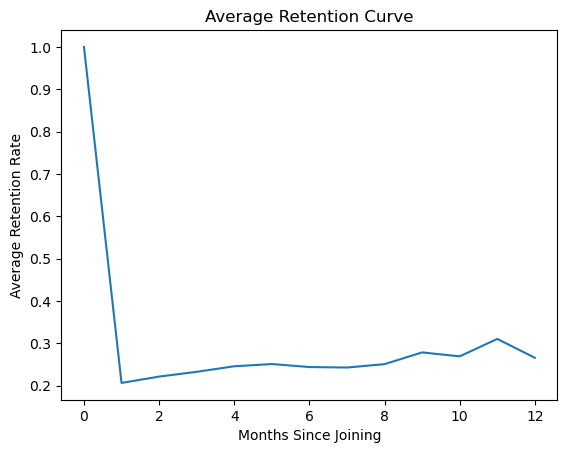

In [21]:
import matplotlib.pyplot as plt
plt.plot(avg_retention.index, avg_retention.values)
plt.title("Average Retention Curve")
plt.xlabel("Months Since Joining")
plt.ylabel("Average Retention Rate")
plt.show()